In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
from portfolio import mean_variance_weights, equal_weight

returns = pd.read_csv("../data/monthly_returns.csv", index_col=0, parse_dates=True)

print("Equal weight:")
print(equal_weight(returns).round(3))

# Sanity check: if every asset has the same expected return,
# the only thing left to optimize is risk
mu_flat = np.full(returns.shape[1], returns.mean().mean())
w_flat = mean_variance_weights(mu_flat, returns.cov().values)

print("\nMean-variance with identical expected returns:")
print(pd.Series(w_flat, index=returns.columns).round(3))

Equal weight:
SPY    0.1
EFA    0.1
EEM    0.1
TLT    0.1
IEF    0.1
LQD    0.1
HYG    0.1
GLD    0.1
VNQ    0.1
DBC    0.1
dtype: float64

Mean-variance with identical expected returns:
SPY    0.008
EFA    0.000
EEM    0.000
TLT    0.000
IEF    0.729
LQD    0.000
HYG    0.144
GLD    0.000
VNQ    0.000
DBC    0.119
dtype: float64


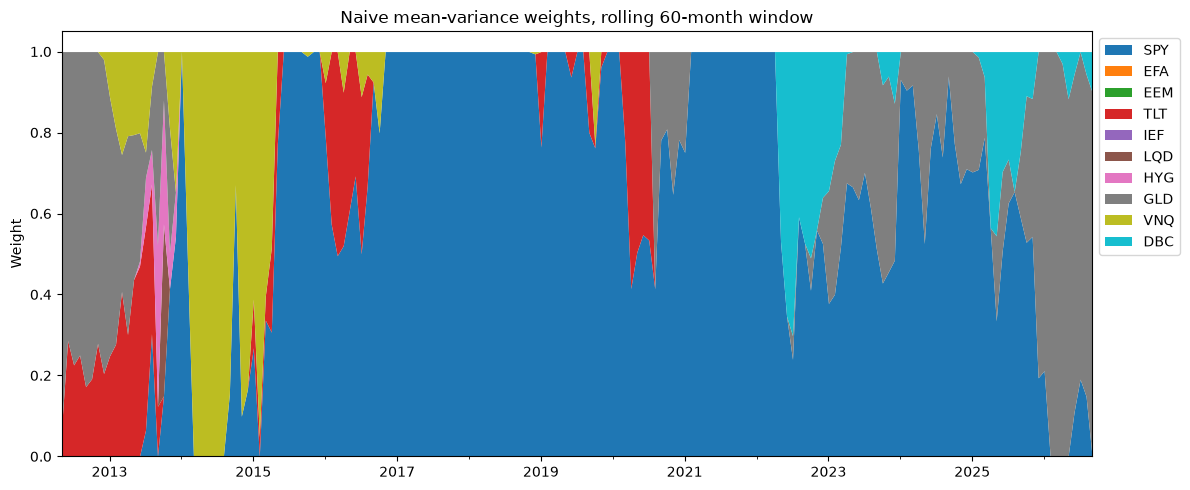

In [2]:
from portfolio import naive_mean_variance, ledoit_wolf_mean_variance
import matplotlib.pyplot as plt

WINDOW = 60  # months of history used for each estimate

def rolling_weights(strategy, returns, window=WINDOW):
    """Weights a strategy would hold each month, using only the previous `window` months."""
    records = {}
    for end in range(window, len(returns)):
        window_returns = returns.iloc[end - window:end]
        records[returns.index[end]] = strategy(window_returns)
    return pd.DataFrame(records).T

naive_w = rolling_weights(naive_mean_variance, returns)

naive_w.plot.area(figsize=(12, 5), linewidth=0,
                  title="Naive mean-variance weights, rolling 60-month window")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

                           naive  ledoit_wolf
avg effective # of assets   1.55         1.56
avg monthly turnover        0.25         0.25


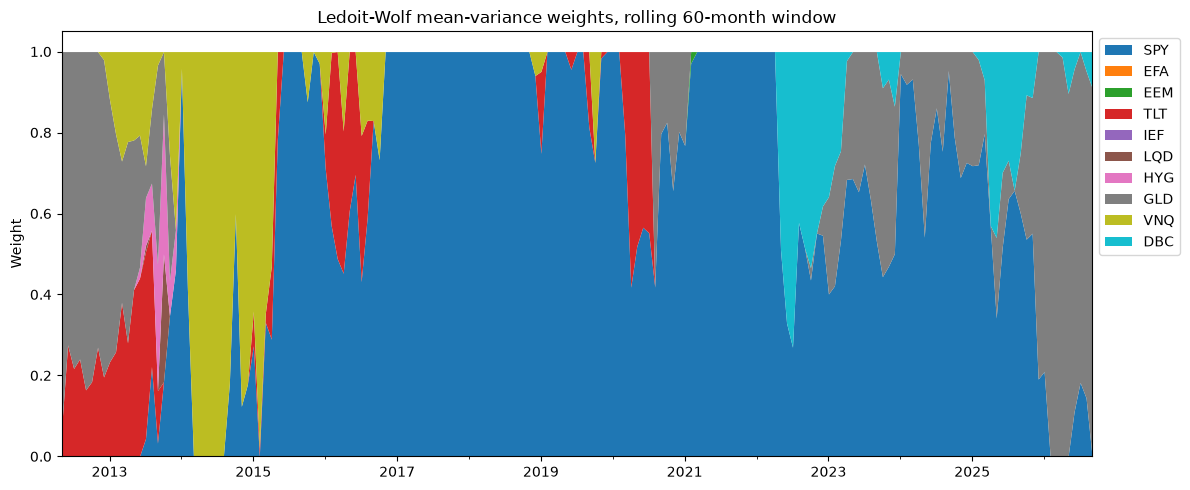

In [3]:
lw_w = rolling_weights(ledoit_wolf_mean_variance, returns)

def effective_n(weights):
    """Effective number of assets held: 1 / sum of squared weights."""
    return 1 / (weights ** 2).sum(axis=1)

def monthly_turnover(weights):
    """Sum of absolute weight changes each month (2.0 = complete portfolio swap)."""
    return weights.diff().abs().sum(axis=1)

comparison = pd.DataFrame({
    "naive": [effective_n(naive_w).mean(), monthly_turnover(naive_w).mean()],
    "ledoit_wolf": [effective_n(lw_w).mean(), monthly_turnover(lw_w).mean()],
}, index=["avg effective # of assets", "avg monthly turnover"])
print(comparison.round(2))

lw_w.plot.area(figsize=(12, 5), linewidth=0,
               title="Ledoit-Wolf mean-variance weights, rolling 60-month window")
plt.ylabel("Weight")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [4]:
from sklearn.covariance import LedoitWolf

shrinkages = [
    LedoitWolf().fit(returns.iloc[end - WINDOW:end].values).shrinkage_
    for end in range(WINDOW, len(returns))
]

print(f"Average Ledoit-Wolf shrinkage intensity: {np.mean(shrinkages):.3f}")
print(f"Range: {np.min(shrinkages):.3f} to {np.max(shrinkages):.3f}")

Average Ledoit-Wolf shrinkage intensity: 0.124
Range: 0.071 to 0.190
